# Logistic Regression (Assignment 1)

This notebook completes Q2(a)-Q2(f) for all logistic datasets.

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from model.metrics import logloss, evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid
from model.utils import get_train_val
from model.linear_model import LinearModel

seed = 42  # do not change
np.random.seed(seed)

DATASETS = [
    'logistic_data_A',
    'logistic_data_B',
    'logistic_data_C',
    'logistic_data_D',
]
LEARNING_RATES = [0.1, 0.01, 0.001]
ITERATION_SETTINGS = [500, 1000, 1500]

asset_dir = Path('report_assets/logistic_regression')
asset_dir.mkdir(parents=True, exist_ok=True)


def save_markdown_table(df, path, float_digits=4):
    out = df.copy()
    for col in out.columns:
        if pd.api.types.is_float_dtype(out[col]):
            out[col] = out[col].map(lambda v: f"{v:.{float_digits}f}")
    header = '| ' + ' | '.join(out.columns) + ' |'
    sep = '| ' + ' | '.join(['---'] * len(out.columns)) + ' |'
    rows = ['| ' + ' | '.join(map(str, row)) + ' |' for row in out.to_numpy()]
    path.write_text('\n'.join([header, sep, *rows]), encoding='utf-8')


def save_loss_curve(train_losses, val_losses, title, save_path):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(range(len(train_losses)), train_losses, color='tab:red', linewidth=1.2, label='Training loss')
    ax.plot(range(len(val_losses)), val_losses, color='tab:green', linewidth=1.2, label='Validation loss')
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.legend(loc='best')
    fig.tight_layout()
    fig.savefig(save_path, dpi=180, bbox_inches='tight')
    plt.show()


def run_logistic_experiment(dataset_name, learning_rate, n_iteration, tag):
    loaded_data = np.load(f'data/logistic_data/{dataset_name}.npz')
    X = loaded_data['X_data']
    y = loaded_data['y_data']
    dim = X.shape[1] - 1

    np.random.seed(seed)
    X_train, y_train, X_val, y_val = get_train_val(X, y)

    model = LinearModel(
        dim=dim,
        is_reg=False,
        loss_fn=logloss,
        grad_fn=logloss_sigmoid_grad,
        act_fn=sigmoid
    )
    model.fit(
        X_train,
        y_train,
        lr=learning_rate,
        n_iteration=n_iteration,
        val_ratio=0.2,
        verbose=False,
        plot_curve=False
    )

    lr_tag = str(learning_rate).replace('.', 'p')
    loss_path = asset_dir / f'{dataset_name}_{tag}_lr_{lr_tag}_iter_{n_iteration}.png'
    save_loss_curve(
        model.train_losses,
        model.val_losses,
        title=f'{dataset_name} ({tag}) - lr={learning_rate}, iter={n_iteration}',
        save_path=loss_path
    )

    y_val_pred = model.predict(X_val)
    metrics = evaluate_binary_classifier(
        y_true=y_val,
        y_pred=y_val_pred,
        title=f'{dataset_name} ({tag}) Evaluation - lr={learning_rate}, iter={n_iteration}'
    )

    return {
        'dataset': dataset_name,
        'learning_rate': learning_rate,
        'n_iteration': n_iteration,
        **metrics,
        'loss_curve_path': str(loss_path),
    }


## Q2(a) and Q2(b): Learning Rate Sweep (`n_iteration=500`)

Dataset: logistic_data_A
--------------------------------------------------------------------------------
Running lr=0.1, n_iteration=500


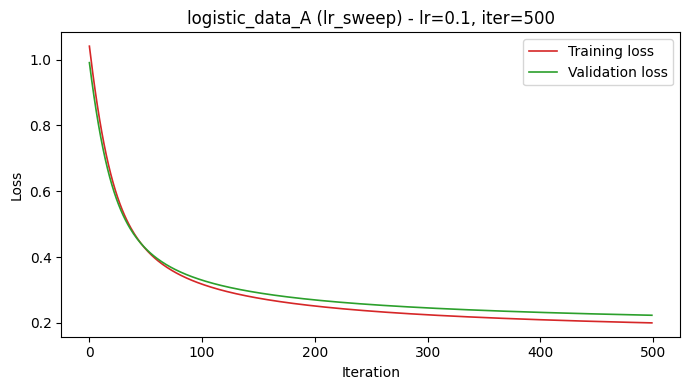

logistic_data_A (lr_sweep) Evaluation - lr=0.1, iter=500
Accuracy  : 0.9050
Precision : 0.9087
Recall    : 0.9171
F1-score  : 0.9128


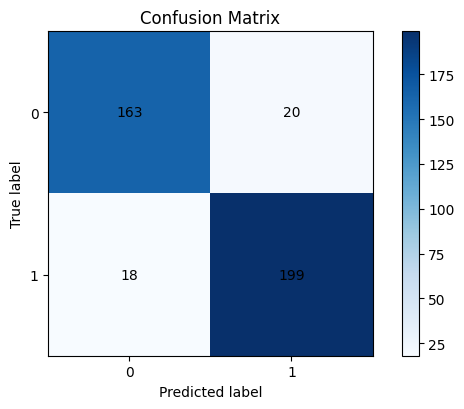

--------------------------------------------------------------------------------
Running lr=0.01, n_iteration=500


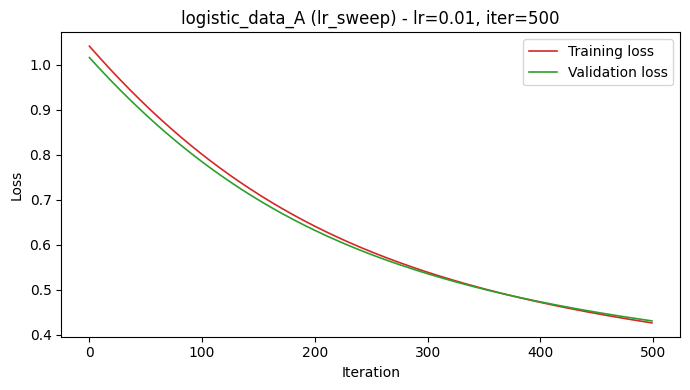

logistic_data_A (lr_sweep) Evaluation - lr=0.01, iter=500
Accuracy  : 0.8775
Precision : 0.8784
Recall    : 0.8986
F1-score  : 0.8884


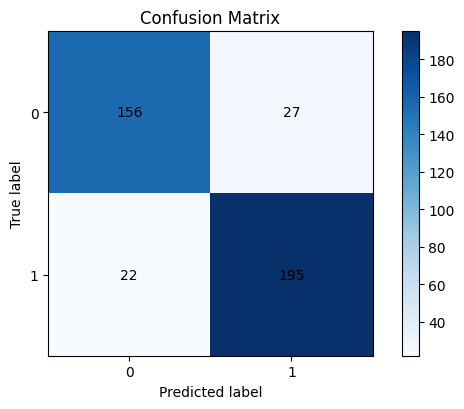

--------------------------------------------------------------------------------
Running lr=0.001, n_iteration=500


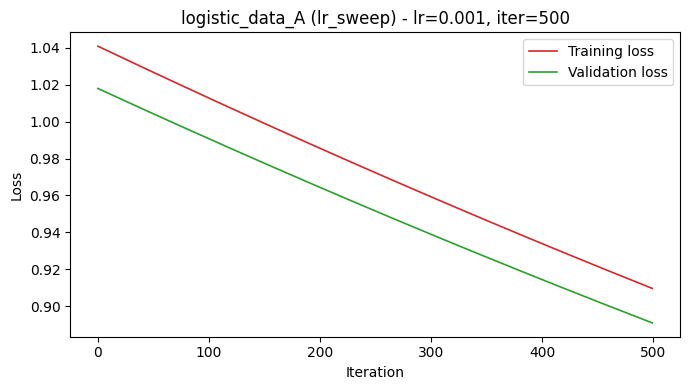

logistic_data_A (lr_sweep) Evaluation - lr=0.001, iter=500
Accuracy  : 0.3875
Precision : 0.4364
Recall    : 0.4424
F1-score  : 0.4394


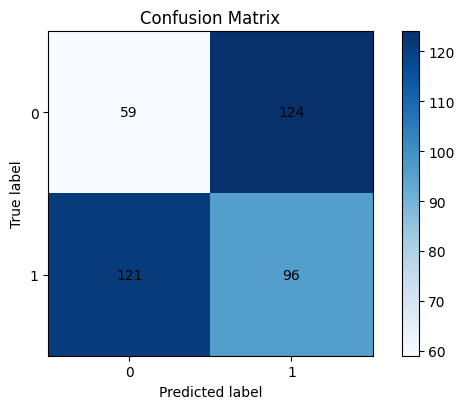

Dataset: logistic_data_B
--------------------------------------------------------------------------------
Running lr=0.1, n_iteration=500


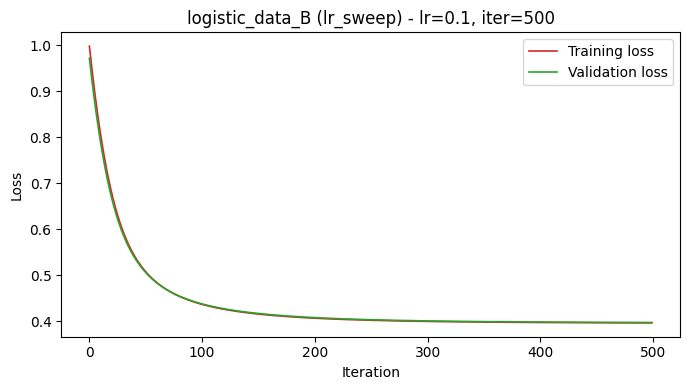

logistic_data_B (lr_sweep) Evaluation - lr=0.1, iter=500
Accuracy  : 0.7800
Precision : 0.7793
Recall    : 0.8160
F1-score  : 0.7972


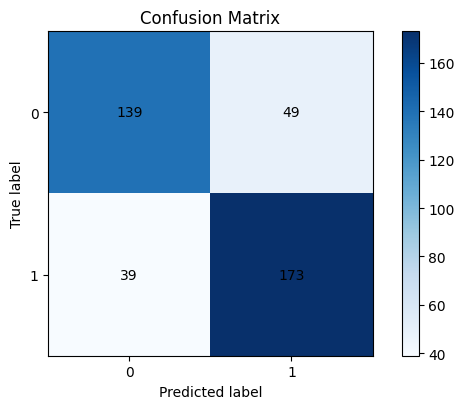

--------------------------------------------------------------------------------
Running lr=0.01, n_iteration=500


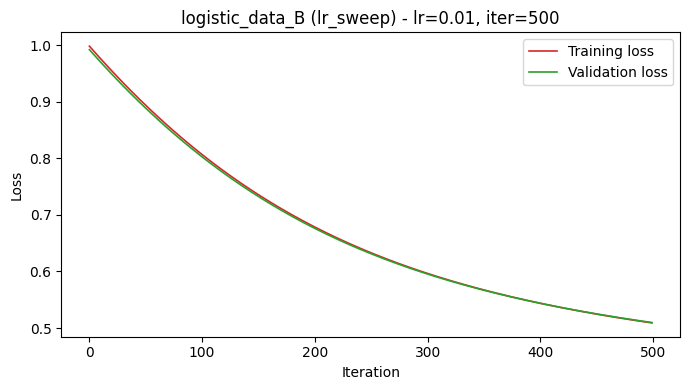

logistic_data_B (lr_sweep) Evaluation - lr=0.01, iter=500


Accuracy  : 0.7625
Precision : 0.7600
Recall    : 0.8066
F1-score  : 0.7826


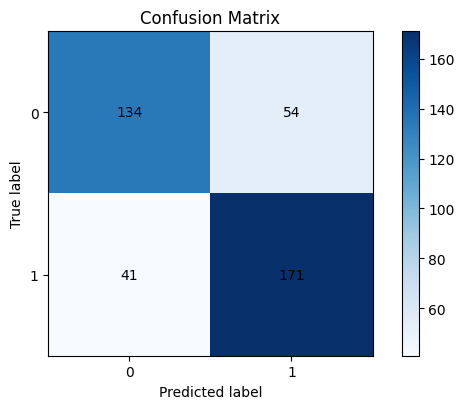

--------------------------------------------------------------------------------
Running lr=0.001, n_iteration=500


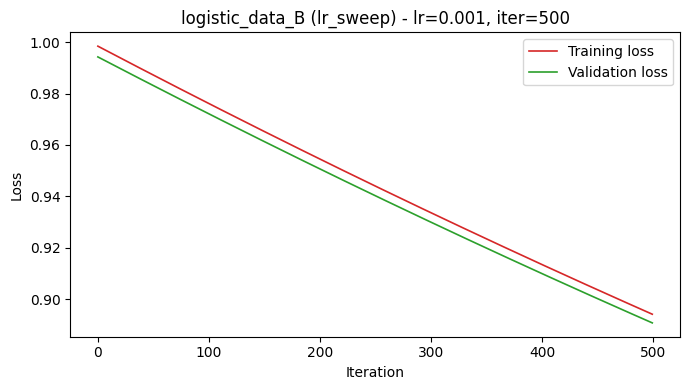

logistic_data_B (lr_sweep) Evaluation - lr=0.001, iter=500
Accuracy  : 0.3925
Precision : 0.4286
Recall    : 0.4387
F1-score  : 0.4336


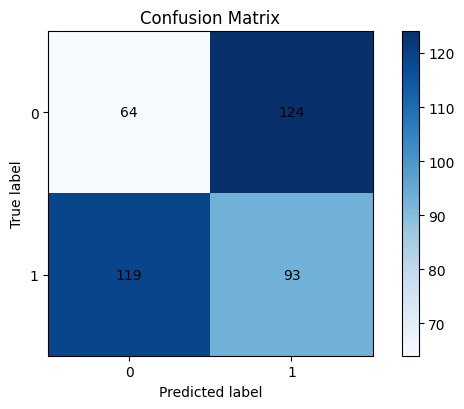

Dataset: logistic_data_C
--------------------------------------------------------------------------------
Running lr=0.1, n_iteration=500


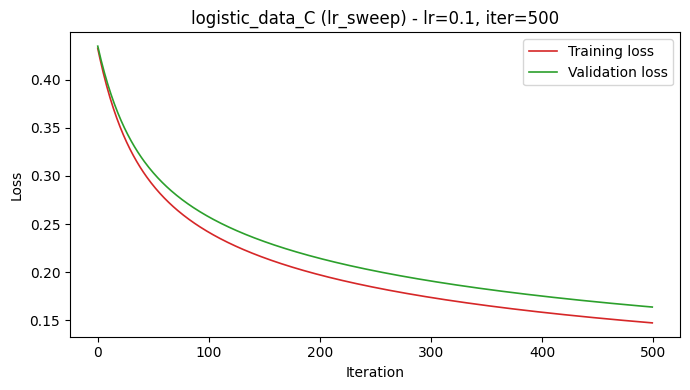

logistic_data_C (lr_sweep) Evaluation - lr=0.1, iter=500
Accuracy  : 0.9762
Precision : 0.9852
Recall    : 0.9719
F1-score  : 0.9785


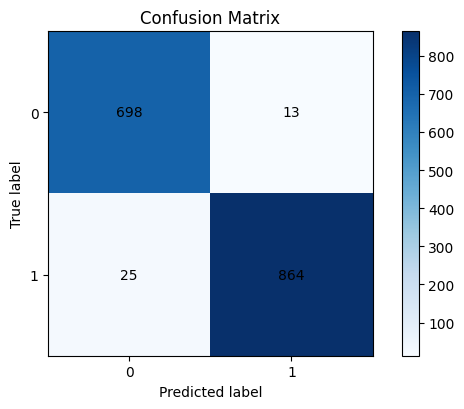

--------------------------------------------------------------------------------
Running lr=0.01, n_iteration=500


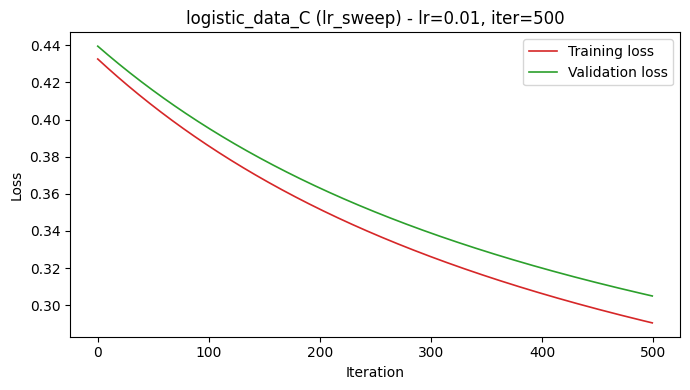

logistic_data_C (lr_sweep) Evaluation - lr=0.01, iter=500
Accuracy  : 0.9456
Precision : 0.9707
Recall    : 0.9303
F1-score  : 0.9500


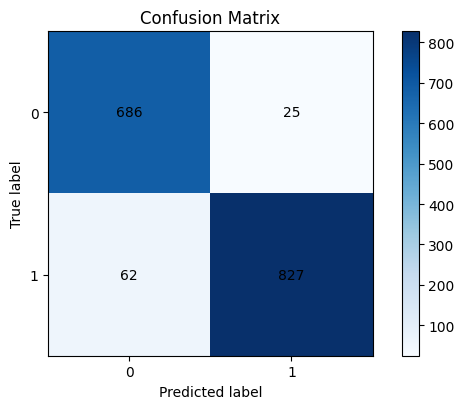

--------------------------------------------------------------------------------
Running lr=0.001, n_iteration=500


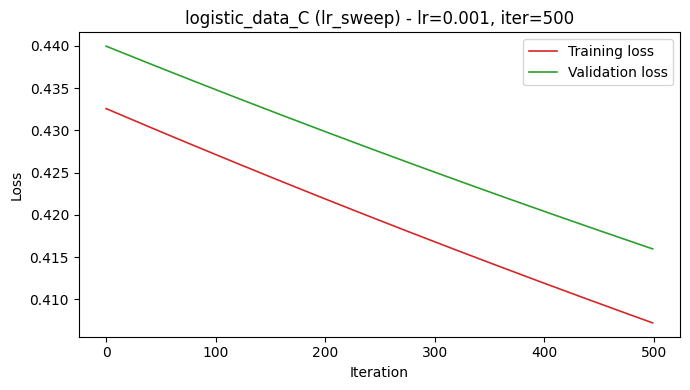

logistic_data_C (lr_sweep) Evaluation - lr=0.001, iter=500
Accuracy  : 0.8406
Precision : 0.8774
Recall    : 0.8290
F1-score  : 0.8525


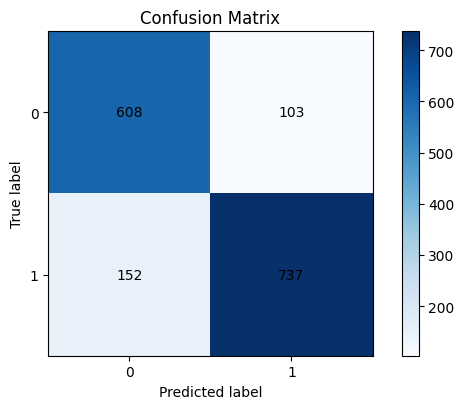

Dataset: logistic_data_D
--------------------------------------------------------------------------------
Running lr=0.1, n_iteration=500


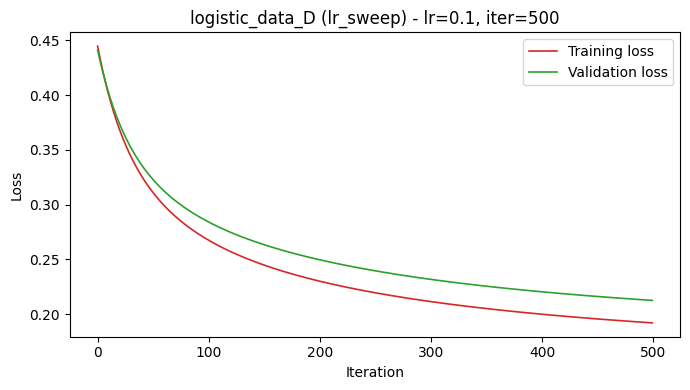

logistic_data_D (lr_sweep) Evaluation - lr=0.1, iter=500
Accuracy  : 0.9225
Precision : 0.9330
Recall    : 0.9266
F1-score  : 0.9298


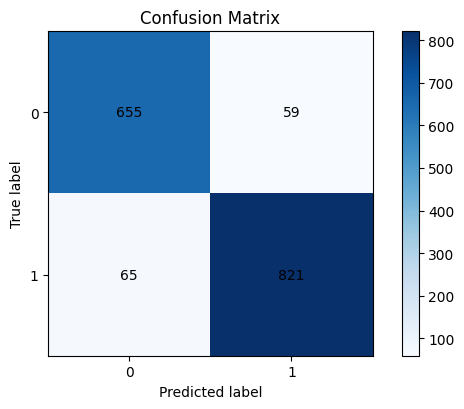

--------------------------------------------------------------------------------
Running lr=0.01, n_iteration=500


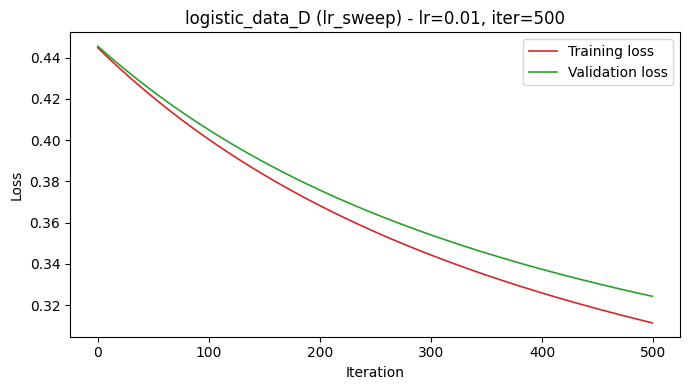

logistic_data_D (lr_sweep) Evaluation - lr=0.01, iter=500
Accuracy  : 0.9113
Precision : 0.9346
Recall    : 0.9029
F1-score  : 0.9185


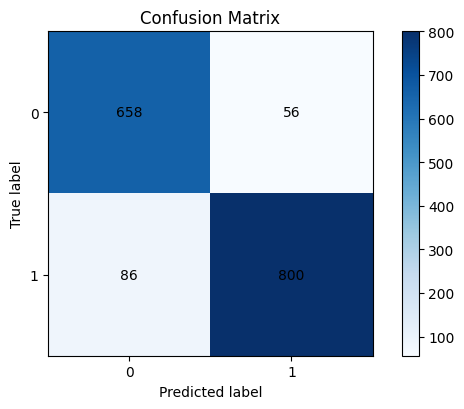

--------------------------------------------------------------------------------
Running lr=0.001, n_iteration=500


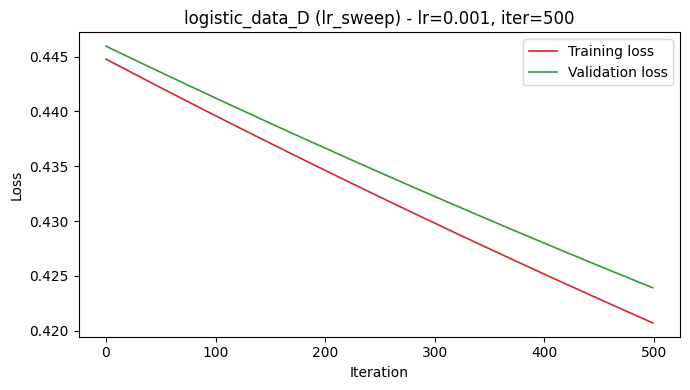

logistic_data_D (lr_sweep) Evaluation - lr=0.001, iter=500
Accuracy  : 0.8319
Precision : 0.8668
Recall    : 0.8228
F1-score  : 0.8442


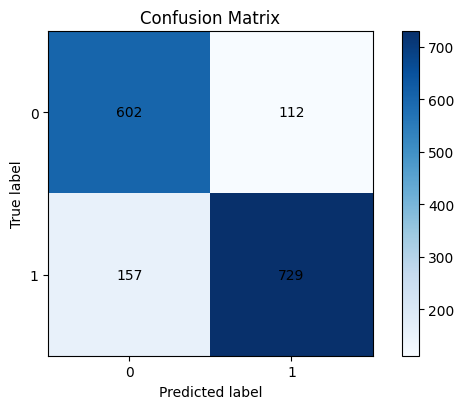

,dataset,learning_rate,n_iteration,Accuracy,Precision,Recall,F1-score,loss_curve_path
0,logistic_data_A,0.100,500,0.905000,0.908676,0.917051,0.912844,report_assets/logistic_regression/logistic_dat...
1,logistic_data_A,0.010,500,0.877500,0.878378,0.898618,0.888383,report_assets/logistic_regression/logistic_dat...
2,logistic_data_A,0.001,500,0.387500,0.436364,0.442396,0.439359,report_assets/logistic_regression/logistic_dat...
3,logistic_data_B,0.100,500,0.780000,0.779279,0.816038,0.797235,report_assets/logistic_regression/logistic_dat...
4,logistic_data_B,0.010,500,0.762500,0.760000,0.806604,0.782609,report_assets/logistic_regression/logistic_dat...
5,logistic_data_B,0.001,500,0.392500,0.428571,0.438679,0.433566,report_assets/logistic_regression/logistic_dat...
6,logistic_data_C,0.100,500,0.976250,0.985177,0.971879,0.978482,report_assets/logistic_regression/logistic_dat...
7,logistic_data_C,0.010,500,0.945625,0.970657,0.930259,0.950029,report_assets/logistic_regression/logistic_dat...
8,logistic_data_C,0.001,500,0.840625,0.877381,0.829021,0.852516,report_assets/logistic_regression/logistic_dat...
9,logistic_data_D,0.100,500,0.922500,0.932955,0.926637,0.929785,report_assets/logistic_regression/logistic_dat...


In [3]:
lr_records = []

for dataset_name in DATASETS:
    print('=' * 80)
    print(f'Dataset: {dataset_name}')
    for lr in LEARNING_RATES:
        print('-' * 80)
        print(f'Running lr={lr}, n_iteration=500')
        result = run_logistic_experiment(
            dataset_name=dataset_name,
            learning_rate=lr,
            n_iteration=500,
            tag='lr_sweep'
        )
        lr_records.append(result)

logistic_lr_df = pd.DataFrame(lr_records)
logistic_lr_df


In [4]:
lr_csv_path = asset_dir / 'logistic_lr_metrics.csv'
lr_md_path = asset_dir / 'logistic_lr_metrics.md'

logistic_lr_df.to_csv(lr_csv_path, index=False)
save_markdown_table(logistic_lr_df, lr_md_path)

print(f'Saved summary CSV: {lr_csv_path}')
print(f'Saved summary Markdown: {lr_md_path}')


Saved summary CSV: report_assets/logistic_regression/logistic_lr_metrics.csv
Saved summary Markdown: report_assets/logistic_regression/logistic_lr_metrics.md


## Q2(c): Observations for Learning Rate Sweep

1. On all datasets, `lr=0.001` performs worse within 500 iterations, indicating slower convergence and underfitting.
2. `lr=0.1` generally gives the strongest validation metrics, while `lr=0.01` is close and more conservative.
3. Dataset `logistic_data_B` is the hardest among the four, with lower accuracy/F1 than A/C/D across learning rates.

## Q2(d) and Q2(e): Iteration Sweep (`lr=0.01`)

Dataset: logistic_data_A
--------------------------------------------------------------------------------
Running lr=0.01, n_iteration=500


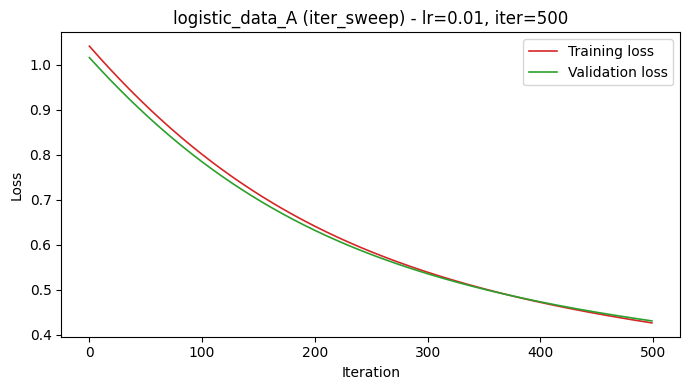

logistic_data_A (iter_sweep) Evaluation - lr=0.01, iter=500
Accuracy  : 0.8775
Precision : 0.8784
Recall    : 0.8986
F1-score  : 0.8884


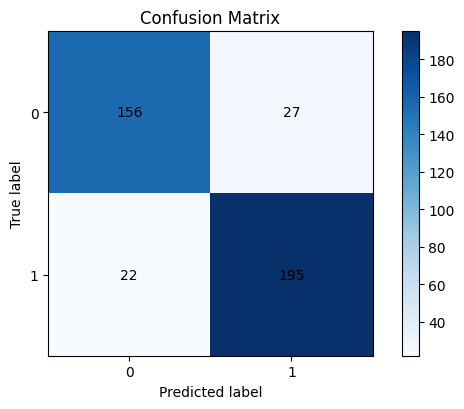

--------------------------------------------------------------------------------
Running lr=0.01, n_iteration=1000


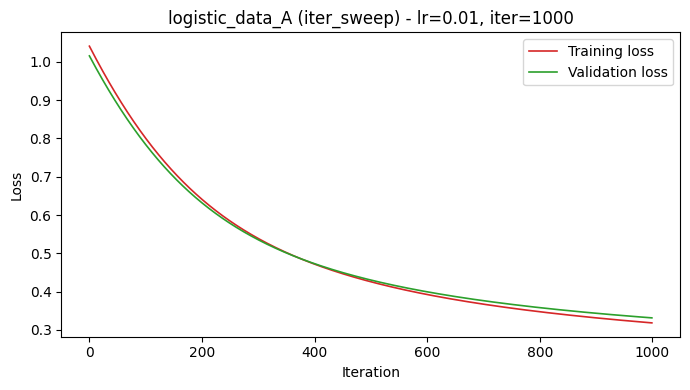

logistic_data_A (iter_sweep) Evaluation - lr=0.01, iter=1000
Accuracy  : 0.9025
Precision : 0.9045
Recall    : 0.9171
F1-score  : 0.9108


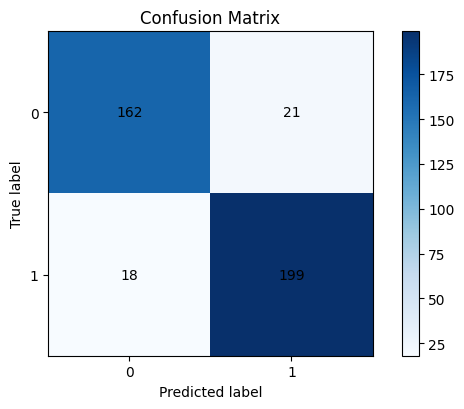

--------------------------------------------------------------------------------
Running lr=0.01, n_iteration=1500


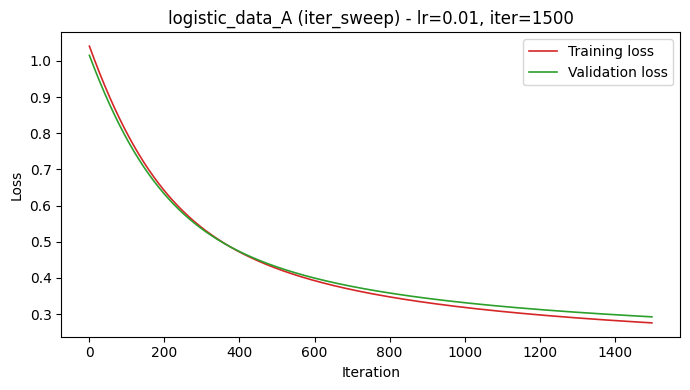

logistic_data_A (iter_sweep) Evaluation - lr=0.01, iter=1500
Accuracy  : 0.9025
Precision : 0.9083
Recall    : 0.9124
F1-score  : 0.9103


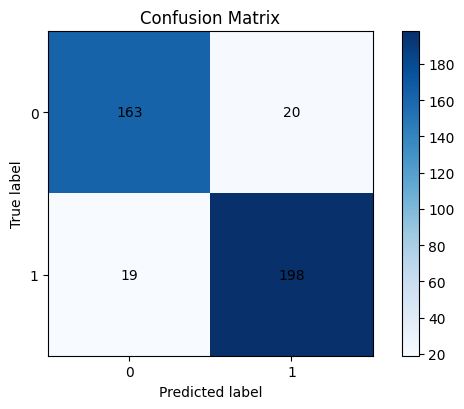

Dataset: logistic_data_B
--------------------------------------------------------------------------------
Running lr=0.01, n_iteration=500


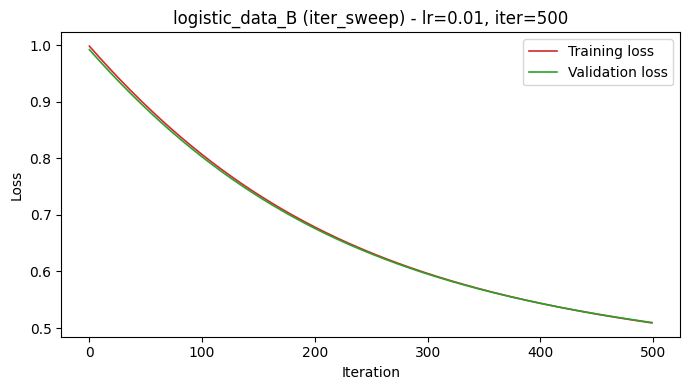

logistic_data_B (iter_sweep) Evaluation - lr=0.01, iter=500
Accuracy  : 0.7625
Precision : 0.7600
Recall    : 0.8066
F1-score  : 0.7826


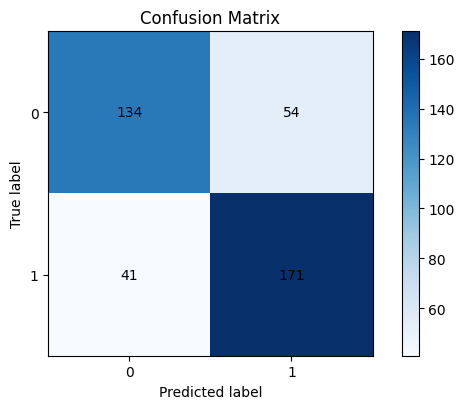

--------------------------------------------------------------------------------
Running lr=0.01, n_iteration=1000


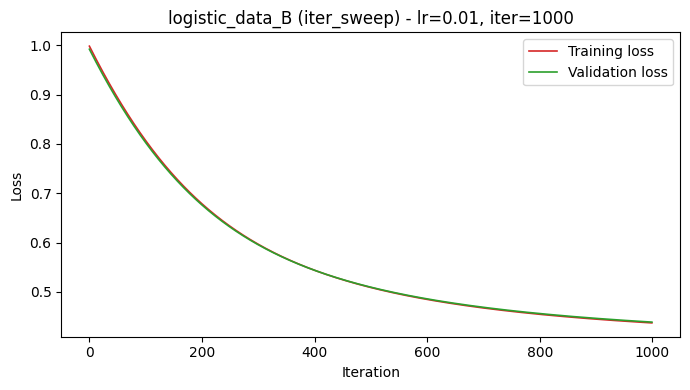

logistic_data_B (iter_sweep) Evaluation - lr=0.01, iter=1000
Accuracy  : 0.7775
Precision : 0.7783
Recall    : 0.8113
F1-score  : 0.7945


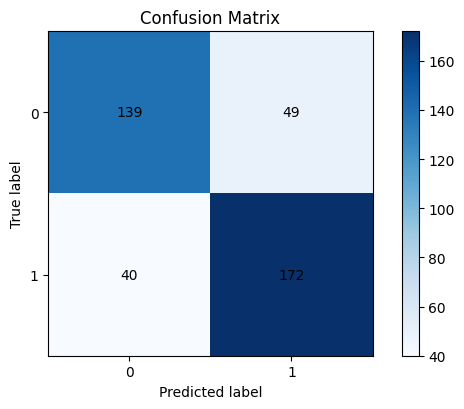

--------------------------------------------------------------------------------
Running lr=0.01, n_iteration=1500


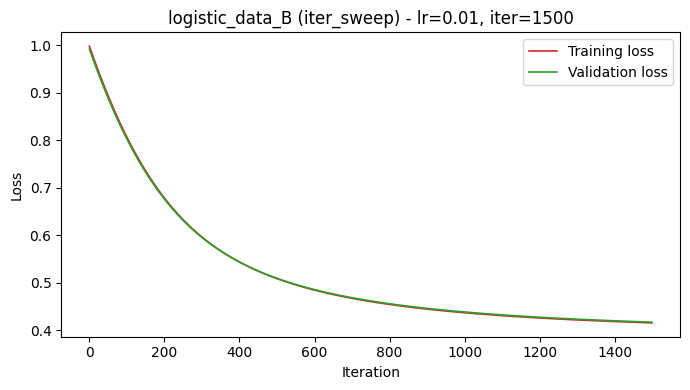

logistic_data_B (iter_sweep) Evaluation - lr=0.01, iter=1500
Accuracy  : 0.7775
Precision : 0.7783
Recall    : 0.8113
F1-score  : 0.7945


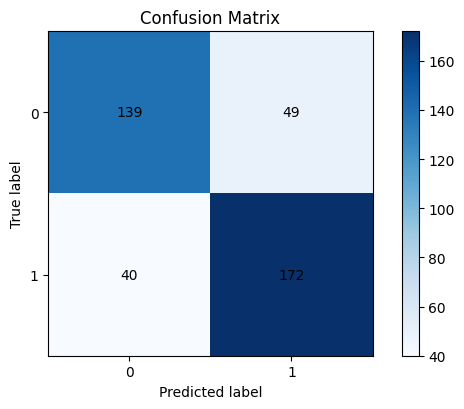

Dataset: logistic_data_C
--------------------------------------------------------------------------------
Running lr=0.01, n_iteration=500


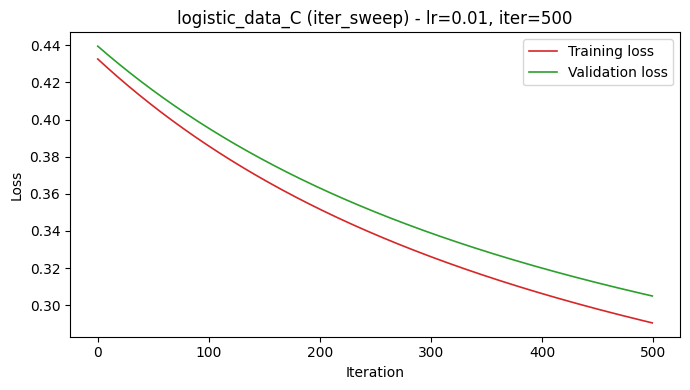

logistic_data_C (iter_sweep) Evaluation - lr=0.01, iter=500
Accuracy  : 0.9456
Precision : 0.9707
Recall    : 0.9303
F1-score  : 0.9500


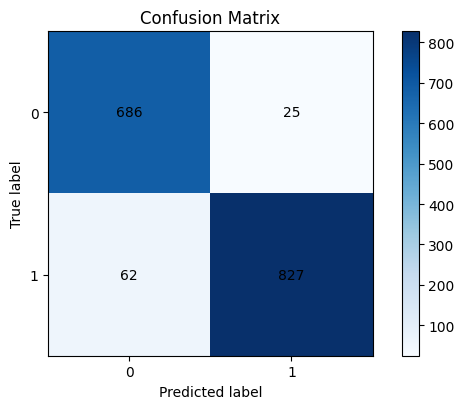

--------------------------------------------------------------------------------
Running lr=0.01, n_iteration=1000


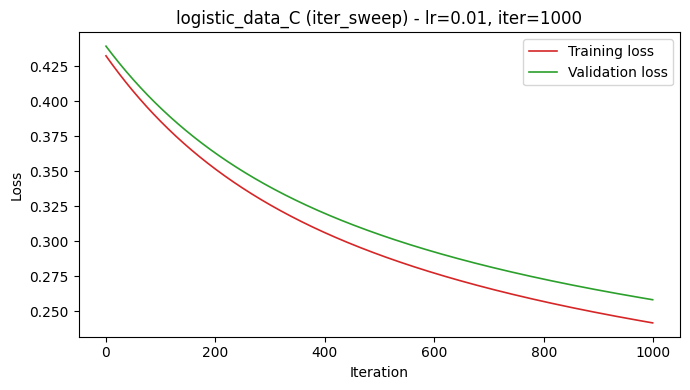

logistic_data_C (iter_sweep) Evaluation - lr=0.01, iter=1000
Accuracy  : 0.9744
Precision : 0.9885
Recall    : 0.9651
F1-score  : 0.9767


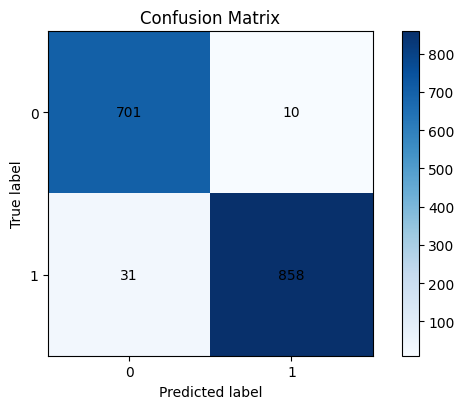

--------------------------------------------------------------------------------
Running lr=0.01, n_iteration=1500


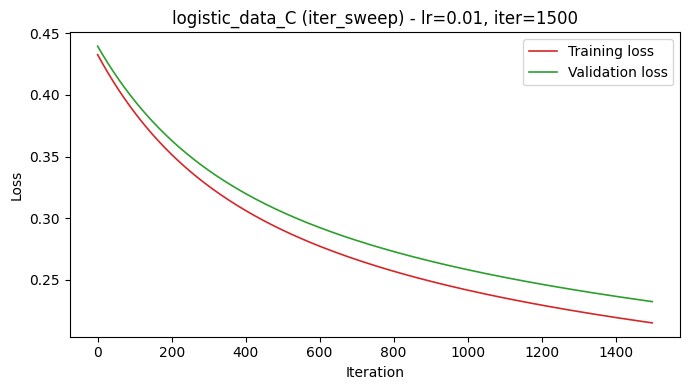

logistic_data_C (iter_sweep) Evaluation - lr=0.01, iter=1500
Accuracy  : 0.9788
Precision : 0.9897
Recall    : 0.9719
F1-score  : 0.9807


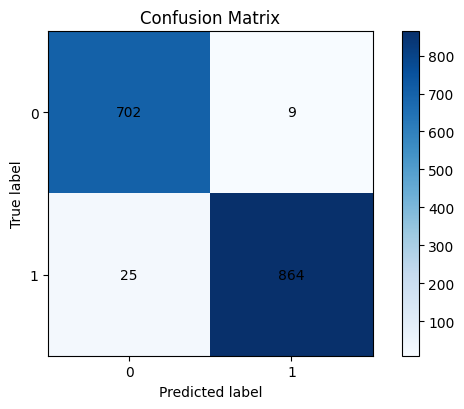

Dataset: logistic_data_D
--------------------------------------------------------------------------------
Running lr=0.01, n_iteration=500


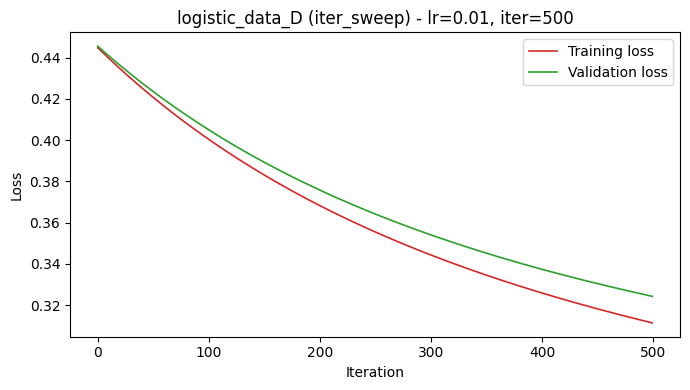

logistic_data_D (iter_sweep) Evaluation - lr=0.01, iter=500
Accuracy  : 0.9113
Precision : 0.9346
Recall    : 0.9029
F1-score  : 0.9185


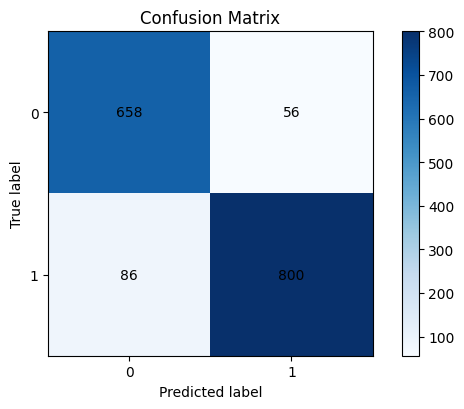

--------------------------------------------------------------------------------
Running lr=0.01, n_iteration=1000


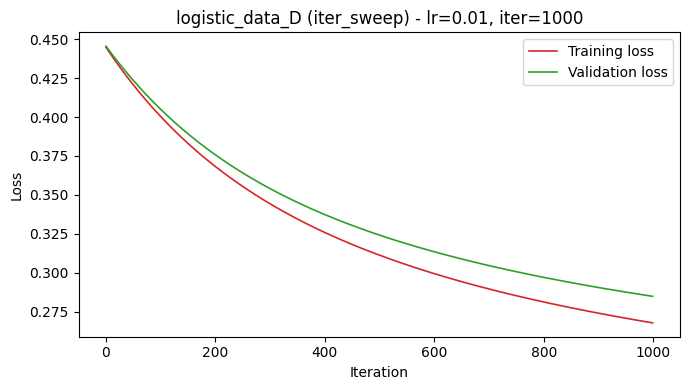

logistic_data_D (iter_sweep) Evaluation - lr=0.01, iter=1000
Accuracy  : 0.9263
Precision : 0.9394
Recall    : 0.9266
F1-score  : 0.9330


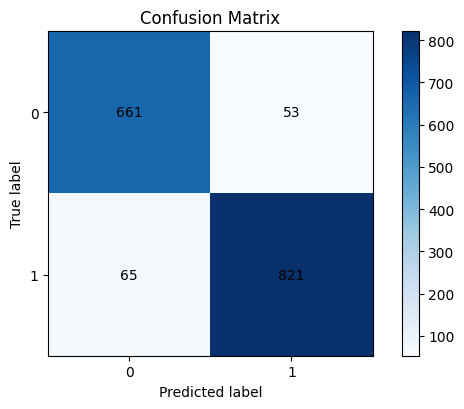

--------------------------------------------------------------------------------
Running lr=0.01, n_iteration=1500


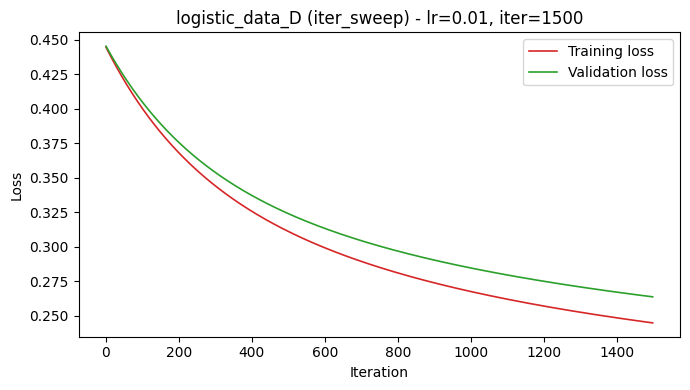

logistic_data_D (iter_sweep) Evaluation - lr=0.01, iter=1500
Accuracy  : 0.9256
Precision : 0.9393
Recall    : 0.9255
F1-score  : 0.9323


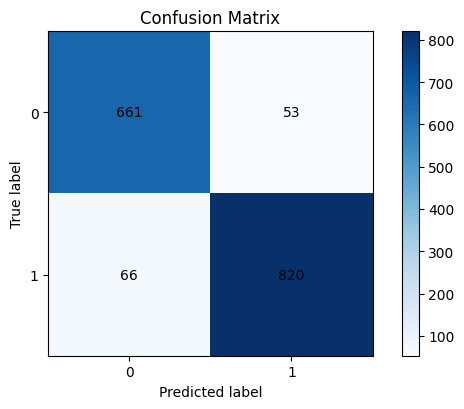

,dataset,learning_rate,n_iteration,Accuracy,Precision,Recall,F1-score,loss_curve_path
0,logistic_data_A,0.01,500,0.877500,0.878378,0.898618,0.888383,report_assets/logistic_regression/logistic_dat...
1,logistic_data_A,0.01,1000,0.902500,0.904545,0.917051,0.910755,report_assets/logistic_regression/logistic_dat...
2,logistic_data_A,0.01,1500,0.902500,0.908257,0.912442,0.910345,report_assets/logistic_regression/logistic_dat...
3,logistic_data_B,0.01,500,0.762500,0.760000,0.806604,0.782609,report_assets/logistic_regression/logistic_dat...
4,logistic_data_B,0.01,1000,0.777500,0.778281,0.811321,0.794457,report_assets/logistic_regression/logistic_dat...
5,logistic_data_B,0.01,1500,0.777500,0.778281,0.811321,0.794457,report_assets/logistic_regression/logistic_dat...
6,logistic_data_C,0.01,500,0.945625,0.970657,0.930259,0.950029,report_assets/logistic_regression/logistic_dat...
7,logistic_data_C,0.01,1000,0.974375,0.988479,0.965129,0.976665,report_assets/logistic_regression/logistic_dat...
8,logistic_data_C,0.01,1500,0.978750,0.989691,0.971879,0.980704,report_assets/logistic_regression/logistic_dat...
9,logistic_data_D,0.01,500,0.911250,0.934579,0.902935,0.918485,report_assets/logistic_regression/logistic_dat...


In [5]:
iter_records = []

for dataset_name in DATASETS:
    print('=' * 80)
    print(f'Dataset: {dataset_name}')
    for n_iter in ITERATION_SETTINGS:
        print('-' * 80)
        print(f'Running lr=0.01, n_iteration={n_iter}')
        result = run_logistic_experiment(
            dataset_name=dataset_name,
            learning_rate=0.01,
            n_iteration=n_iter,
            tag='iter_sweep'
        )
        iter_records.append(result)

logistic_iter_df = pd.DataFrame(iter_records)
logistic_iter_df


In [6]:
iter_csv_path = asset_dir / 'logistic_iteration_metrics.csv'
iter_md_path = asset_dir / 'logistic_iteration_metrics.md'

logistic_iter_df.to_csv(iter_csv_path, index=False)
save_markdown_table(logistic_iter_df, iter_md_path)

print(f'Saved summary CSV: {iter_csv_path}')
print(f'Saved summary Markdown: {iter_md_path}')


Saved summary CSV: report_assets/logistic_regression/logistic_iteration_metrics.csv
Saved summary Markdown: report_assets/logistic_regression/logistic_iteration_metrics.md


## Q2(f): Observations for Iteration Sweep

1. Increasing iterations from 500 to 1000 usually improves all metrics.
2. The gain from 1000 to 1500 is smaller on most datasets, suggesting diminishing returns.
3. For practical efficiency, `lr=0.01` with around `1000` iterations is a reasonable trade-off for this assignment.